# Solphin with CASTEP

`solphin`'s workflow is the same whichever code produces the data: relax the structure, run a spectral calculation for the density of states and the dielectric function, run a band structure, then feed the resulting band gap, effective mass, dielectric constant and absorption spectrum into detailed balance and the photovoltaic figure of merit.

This notebook walks that workflow with CASTEP. Two things differ from the [VASP walkthrough](https://solphin.readthedocs.io/en/latest/full_workflow_tutorial.html):

* **Input generation** has its own module, `solphin.castep_inputs`, which writes a `<seed>.cell` / `<seed>.param` pair where `solphin.vasp_inputs` writes `INCAR`, `POSCAR`, `KPOINTS` and `POTCAR`. The recipe and patch vocabulary is the same for both.
* **Reading output** goes through the `code="castep"` keyword that every reader takes. CASTEP spreads over seed-named files what VASP concentrates in `vasprun.xml`: eigenvalues in `<seed>.bands`, and the dielectric function in the `<seed>_epsilon.dat` written by [OptaDOS](https://github.com/optados-developers/optados).

Everything downstream of the absorption spectrum — spectral averages, SLME, detailed balance, the figure of merit — is code-agnostic and takes no `code` argument at all.

The ["Using solphin with CASTEP"](https://solphin.readthedocs.io/en/latest/castep.html) page is the reference for what maps to what; this notebook is the worked version of it. Nothing here runs CASTEP or OptaDOS: neither is a dependency of `solphin`, and no CASTEP installation is needed to follow along.

In [1]:
# Import the required modules

import logging
import shutil
import warnings
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import solphin.band_structure as band_structure
import solphin.castep_inputs as castep_inputs
import solphin.db_fom as db_fom
import solphin.db_plots as db_plots
import solphin.dos as dos
import solphin.final_results as final_results
import solphin.optics as optics
import solphin.spectral as spectral
import solphin.vasp_inputs as vasp_inputs

# Draw figures in the notebook. JupyterLab does this by default; saying it
# explicitly means the notebook also draws when it is executed headlessly,
# which is how the copy committed to the repository is produced.
%matplotlib inline

# Filters are the application's to set too. sumo reads spglib's dataset
# through the mapping interface spglib 2.5 deprecated, in the k-path code
# called below; solphin never imports spglib itself, so there is nothing here
# to act on. This is the same filter pyproject.toml applies to the test suite.
warnings.filterwarnings("ignore", message="dict interface is deprecated", category=DeprecationWarning)

# solphin does not configure logging - that is the application's job, and here
# the notebook is the application. sumo reports the k-path and structure
# symmetry through the root logger at INFO, so opt in to see it; matplotlib's
# font_manager is turned down because sumo's style sheet asks for fonts
# (cursive, sans:semibold) that no machine has, and the fallback is fine.
logging.basicConfig(level=logging.INFO)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

## Where files are read from and written to

This notebook never runs the calculations it sets up, so the outputs analysed in the second half cannot have come from the inputs generated in the first. Both halves read data tracked in the repository, and both write only into `workdir/castep/`:

* **Input generation** starts from `../tests/data/Cu2GeS3/Relax/CONTCAR`, the same relaxed Cu₂GeS₃ structure the VASP tutorial uses, so the two input sets can be read side by side.
* **Analysis** reads `../tests/data/castep_toy/`, the synthetic CASTEP set the test suite runs against. Real CASTEP and OptaDOS output for a material like Cu₂GeS₃ is far too large to ship; these files are small, hand-built and closed-form, and `tests/castep_fixtures.py` documents and regenerates every one of them. For a tutorial that is better than a black box, because the right answer is known in advance and each reader can be checked against it:

  | Quantity | Fixture | Value it encodes |
  |---|---|---|
  | Band gap | `BAND/toy.bands` (+ `toy.cell`) | 1.5 eV, direct at Γ |
  | DOS effective masses | `DOS/toy.bands` | 0.30 mₑ electrons, 1.20 mₑ holes |
  | Static dielectric constant | `OPT/toy_epsilon.dat` | ε(0) = 6, from a Lorentz oscillator |

  It is a toy: one Si atom in a 5 Å cube, four cosine bands, a single oscillator. Read every number the second half produces as evidence that the reader works, not as physics.
* `workdir/castep/` is generated and disposable, and gitignored. The `castep/` level keeps this notebook's output from landing on top of the VASP tutorial's, which writes into the same `workdir/`. Nothing either notebook writes goes near the tracked data it reads, so re-running this one leaves `../tests/data/` byte-identical.

## Global settings

These apply to every calculation in the workflow and are the first choices of any DFT study:

* **`cut_off_energy`** — the plane-wave cut-off in eV, CASTEP's equivalent of `ENCUT`. Converge it for your system.
* **`kpoint_mp_spacing`** — the maximum k-point spacing in Å⁻¹. CASTEP omits the 2π that VASP's `KSPACING` carries, so the numbers are not interchangeable: the `0.03` used here corresponds to `KSPACING ≈ 0.19`.
* **A functional.** Hybrid DFT (HSE06 or PBE0) is recommended for publishable PV work. In CASTEP hybrids require norm-conserving pseudopotentials, and the `HSE06` and `PBE0` recipes ask for the `NCP19` library accordingly. There is no POTCAR equivalent to set up — CASTEP generates pseudopotentials on the fly — so unlike the VASP workflow this one needs no `$HOME/.pmgrc.yaml`.

In [2]:
functional = "HSE06"  # The DFT functional
cut_off_energy = 450  # Plane-wave cut-off in eV (CASTEP's ENCUT)
kpoint_mp_spacing = 0.03  # Maximum k-point spacing in Angstrom^-1, no 2*pi factor

# Read roots, both tracked in git and never written to by this notebook: the
# starting structure comes from the VASP reference set, the CASTEP output
# analysed later from the synthetic fixture set.
initial_structure = "../tests/data/Cu2GeS3/Relax/CONTCAR"
castep_data = Path("../tests/data/castep_toy")

# Write root: everything this notebook generates. Disposable and gitignored.
workdir = Path("workdir/castep")
workdir.mkdir(parents=True, exist_ok=True)

## Generating CASTEP input files

### Geometry optimisation

The first step of a structural study is a geometry optimisation. `write_castep_calculation` takes the same arguments as `write_vasp_calculation` — a structure, a recipe, an output directory and a list of patches — and returns the path of the `.cell` file it wrote. That return value matters more here than it does for VASP: the seed name is derived from the structure unless you pass `seedname=`, and every later step (the band structure setup, OptaDOS) needs to know it.

The starting structure can come from the ICSD, the Materials Project or an experimental study. `read_structure_pmg` accepts POSCAR/CONTCAR, `.cif`, `.xyz` and `.json` as before, and CASTEP `.cell` files as well.

In [3]:
# Load the structure
structure = vasp_inputs.read_structure_pmg(initial_structure)

# Generate the calculation
relax_cell = castep_inputs.write_castep_calculation(
    structure=structure,
    recipe=functional,
    out_dir=workdir / "Relax",
    patches=["relax_cell", "tight_relax"],
    kpoint_mp_spacing=kpoint_mp_spacing,
    user_param_settings={"cut_off_energy": cut_off_energy},
)

print(relax_cell)

workdir/castep/Relax/Cu2GeS3.cell


The pair of files that produces is short enough to read in full. Everything a CASTEP run needs is in them: the structure, k-point sampling and pseudopotential library in the `.cell`, the task and its convergence settings in the `.param`.

In [4]:
relax_param = relax_cell.with_suffix(".param")

print(f"--- {relax_cell.name} ---")
print(relax_cell.read_text())
print(f"--- {relax_param.name} ---")
print(relax_param.read_text())

--- Cu2GeS3.cell ---
symmetry_generate       : true
kpoint_mp_spacing       : 0.03

%block lattice_cart
ang
3.2283573777284738 5.6613995915914845 0.0
-3.2283573777284738 5.6613995915914845 0.0
-2.048279566216239 0.0 6.111657191170746
%endblock lattice_cart

%block positions_frac
Cu 0.8684930462903437 -0.3726056519635159 0.8590804455420348
Cu 0.3726056519635159 0.1315069537096563 0.3590804455420349
Cu 0.2000102284177255 -0.0263041952043245 0.8598040627651895
Cu 1.0263041952043244 -0.2000102284177255 0.3598040627651895
Ge 0.5524141063996324 0.2754575596967332 0.880829184367114
Ge 0.7245424403032668 -0.5524141063996324 0.3808291843671139
S 0.7408431770580568 -0.2555119484014365 0.4837465690005931
S 1.2555119484014365 -0.7408431770580568 0.9837465690005931
S 1.0792914722567069 -0.9114663703967381 0.4813333455830126
S 0.9114663703967382 -0.079291472256707 0.9813333455830126
S 0.5792789205765068 -0.4212464627317385 0.0002063927420672
S 0.4212464627317385 0.4207210794234932 0.5002063927420672

Two settings in there are worth a note, because their VASP counterparts are not equivalent:

* `elec_energy_tol` is an energy **per atom**, where VASP's `EDIFF` is a total energy. The recipes use `1e-7` eV/atom to mirror `EDIFF = 1e-6`, tightened to `1e-9` by the `tight_relax` patch.
* `perc_extra_bands` sets the empty-band count as a percentage rather than the absolute `NBANDS`. A spectral or optics calculation needs plenty of empty bands, and 50% is a starting point, not a converged choice.

Run the calculation the way your machine wants CASTEP run — for example:

```bash
cd workdir/castep/Relax
mpirun -np 16 castep.mpi Cu2GeS3
```

CASTEP writes the relaxed structure to `<seed>-out.cell`, which is the file the rest of the workflow builds on. `read_structure_pmg` reads it through sumo, since pymatgen has no CASTEP `.cell` reader of its own:

```python
structure = vasp_inputs.read_structure_pmg("workdir/castep/Relax/Cu2GeS3-out.cell")
```

This notebook does not run CASTEP, so there is no `-out.cell` to read. To show the reader working, the cell below round-trips the `.cell` just written instead; on your own material, read the relaxed one.

In [5]:
# Stand-in for the -out.cell a finished geometry optimisation would leave
structure = vasp_inputs.read_structure_pmg(relax_cell)

print(structure)

Full Formula (Cu4 Ge2 S6)
Reduced Formula: Cu2GeS3
abc   :   6.517188   6.517188   6.445759
angles:  80.943315  99.056685  59.387049
pbc   :       True       True       True
Sites (12)
  #  SP           a          b         c
---  ----  --------  ---------  --------
  0  Cu    0.868493  -0.372606  0.85908
  1  Cu    0.372606   0.131507  0.35908
  2  Cu    0.20001   -0.026304  0.859804
  3  Cu    1.0263    -0.20001   0.359804
  4  Ge    0.552414   0.275458  0.880829
  5  Ge    0.724542  -0.552414  0.380829
  6  S     0.740843  -0.255512  0.483747
  7  S     1.25551   -0.740843  0.983747
  8  S     1.07929   -0.911466  0.481333
  9  S     0.911466  -0.079291  0.981333
 10  S     0.579279  -0.421246  0.000206
 11  S     0.421246   0.420721  0.500206


### Density of states and optical absorption

These are the calculations that produce the optoelectronic data the figure of merit needs. Both are CASTEP's `Spectral` task, differing in `spectral_task`:

* the `dos` patch sets `spectral_task: DOS` and switches on PDOS weights, giving a `<seed>.bands` (and `.pdos_bin`) for the density of states and the effective-mass fit;
* the `optics` patch sets `spectral_task: Optics`, which writes the optical matrix elements (`<seed>.ome_bin`) that OptaDOS turns into a dielectric function.

Both want a dense k-point mesh and generous empty bands: the shape of the DOS and of the absorption spectrum has to be converged with respect to `kpoint_mp_spacing` and `perc_extra_bands`, exactly as it does with respect to `KSPACING` and `NBANDS` in VASP.

In [6]:
dos_out = workdir / "DOS"
optics_out = workdir / "OPT"

castep_inputs.write_castep_calculation(
    structure=structure,
    recipe=functional,
    out_dir=dos_out,
    patches=["dos"],
    kpoint_mp_spacing=kpoint_mp_spacing,
    user_param_settings={"cut_off_energy": cut_off_energy},
)

optics_cell = castep_inputs.write_castep_calculation(
    structure=structure,
    recipe=functional,
    out_dir=optics_out,
    patches=["optics"],
    kpoint_mp_spacing=kpoint_mp_spacing,
    user_param_settings={"cut_off_energy": cut_off_energy},
)

print(f"--- {optics_cell.with_suffix('.param').name} ---")
print(optics_cell.with_suffix(".param").read_text())

--- Cu2GeS3.param ---
task                    : Spectral
xc_functional           : HSE06
cut_off_energy          : 450
elec_energy_tol         : 1e-07
max_scf_cycles          : 200
fix_occupancy           : false
smearing_scheme         : Gaussian
smearing_width          : 0.02
perc_extra_bands        : 50
write_checkpoint        : All
spectral_task           : Optics



#### Running OptaDOS

CASTEP stops at the optical matrix elements; the dielectric function itself comes from OptaDOS, a Fortran post-processing tool distributed alongside CASTEP. With the optics run finished, put a `<seed>.odi` beside its output and run `optados <seed>`. A minimal one:

```
task         : optics
optics_geom  : polycrystalline
broadening   : adaptive
jdos_spacing : 0.01
```

That writes `<seed>_epsilon.dat`, which is the file `solphin` reads. Two of its settings reach the numbers below:

* **`optics_geom`.** Both the default `polycrystalline` and `tensor` are understood; a polycrystalline spectrum is treated as an isotropic tensor. There is no VASP counterpart to the choice.
* **Broadening** is an OptaDOS setting, not a CASTEP one — which is why solphin's `smeared_optics` patch, unlike its VASP twin, changes nothing about the CASTEP input. Set it here.

The fixture read in the second half of this notebook is a polycrystalline `_epsilon.dat` in exactly this format.

### Band structure

The band structure gives the band gap the figure of merit is built on. Choosing the high-symmetry path is shared with the VASP workflow: the path definition needs a canonical orientation of the cell, so `generate_band_structure_path` returns a canonical structure alongside the path and it is that structure the calculation must use.

In [7]:
# Calculate the high-symmetry path, and with it the canonical orientation
canonical_structure, band_path = band_structure.generate_band_structure_path(
    structure=structure,
    definition="bradcrack",
)

INFO:root:Structure information:


INFO:root:	Space group number: 9


INFO:root:	International symbol: Cc


INFO:root:	Lattice type: monoclinic


INFO:root:
k-point path:
	\Gamma -> Y -> V -> \Gamma -> A -> M -> L -> V


...

INFO:root:	M: 0.5 0.5 0.5


INFO:root:	L: 0.5 0.0 0.5


INFO:root:	V: 0.5 0.0 0.0


INFO:root:	Y: 0.5 0.5 0.0


Generated high-symmetry path of 239 k-points


Where a VASP band structure restarts from a converged `CHGCAR`, a CASTEP one restarts from the SCF run's `.check` file. `write_castep_band_structure_calculation` therefore builds on a finished calculation rather than on a bare structure: point it at the SCF `.cell` — the optics one above will do — and it appends the k-path to a copy of that cell as a `spectral_kpoint_list`, copies the `.param` with the task switched to `Spectral` / `BandStructure`, and copies the `.check` beside it with `reuse` set.

Since k-points are independent, the path can be split across parallel calculations, which is usually only worth doing for a hybrid functional. Unlike the VASP setup there are no extra SCF k-points to fold in: the `reuse` file carries the converged density.

The setup refuses to write into a directory that already holds `split-*` folders, rather than mixing two runs' k-points together, so the cell below clears its own output from any previous run of this notebook first.

In [8]:
band_out = workdir / "BAND"
splits = 5  # How many parallel calculations to split the k-point path across

# Clear the previous run's split-* folders; only ever workdir/castep/BAND.
shutil.rmtree(band_out, ignore_errors=True)

band_structure.write_castep_band_structure_calculation(
    optics_cell,
    band_path,
    band_out,
    splits=splits,
)

for path in sorted(band_out.rglob("*")):
    print(path)

workdir/castep/BAND/split-01
workdir/castep/BAND/split-01/Cu2GeS3.cell
workdir/castep/BAND/split-01/Cu2GeS3.param
workdir/castep/BAND/split-02
workdir/castep/BAND/split-02/Cu2GeS3.cell
workdir/castep/BAND/split-02/Cu2GeS3.param
workdir/castep/BAND/split-03
workdir/castep/BAND/split-03/Cu2GeS3.cell
workdir/castep/BAND/split-03/Cu2GeS3.param
workdir/castep/BAND/split-04
workdir/castep/BAND/split-04/Cu2GeS3.cell
workdir/castep/BAND/split-04/Cu2GeS3.param
workdir/castep/BAND/split-05
workdir/castep/BAND/split-05/Cu2GeS3.cell
workdir/castep/BAND/split-05/Cu2GeS3.param


No `.check` appears in those folders here, because this notebook never ran the SCF calculation that would have produced one. Run the optics calculation first and the file is picked up automatically, and each split then starts from the converged density instead of repeating the SCF.

### Effective-mass inputs

`write_eff_mass` generates a dense local k-point mesh around a band edge. On the CASTEP side that becomes a spectral band-structure run with an explicit `spectral_kpoint_list`, in place of VASP's INCAR tags and KPOINTS mesh. The band-edge k-point is Γ for this structure; read yours off the band structure.

In [9]:
dos.write_eff_mass(
    k0_frac=np.array([0.0, 0.0, 0.0]),
    structure=canonical_structure,
    functional=functional,
    encut=cut_off_energy,
    folder=str(workdir / "eff_mass"),
    code="castep",
)

print(sorted(p.name for p in (workdir / "eff_mass").iterdir()))

['Cu2GeS3.cell', 'Cu2GeS3.param']


## Analysing the results of CASTEP calculations

From here on the notebook reads the synthetic CASTEP set described at the top: a one-atom cubic cell with a 1.5 eV direct gap at Γ, DOS effective masses of 0.30 mₑ and 1.20 mₑ, and a Lorentz-oscillator dielectric function with ε(0) = 6 exactly. Each result below can be checked against the value the fixture encodes.

### Density of states

`plot_dos`, `compute_dos` and `get_dos_effective_mass` take the `<seed>.bands` file where they take a `vasprun.xml` for VASP. Sibling `.pdos_bin` and `.cell` files are picked up automatically when they exist, which is what makes an orbital-projected DOS possible; the fixture has neither, so what follows is the total DOS.

INFO:root:PDOS not available, falling back to TDOS.


INFO:root:Reading CASTEP .bands file header...


INFO:root:nbands: 2, efermi / Ry: 0.027561991863, spin channels: 1


INFO:root:Reading band eigenvalues...


INFO:root:Electronic structure appears to have a bandgap


INFO:root:Setting energy zero to VBM


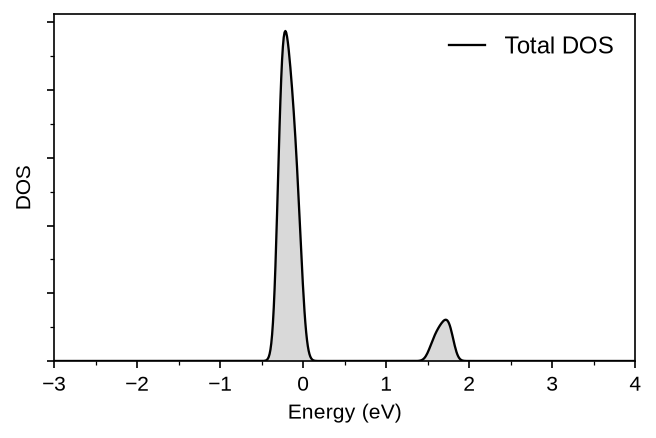

In [10]:
dos.plot_dos(filename=str(castep_data / "DOS" / "toy.bands"), xmin=-3, xmax=4, gaussian=0.05, code="castep")

CASTEP has no `NEDOS`: its density of states is histogrammed from the eigenvalues, and the `bin_width` keyword (0.01 eV by default) plays that role. The interaction to watch is between the bin width, the density of the spectral k-point mesh and the fitting window — the √E fit needs enough bins inside the window to have something to fit, and enough k-points that each bin is well sampled.

In [11]:
result = dos.compute_dos(
    dos_vasprun=str(castep_data / "DOS" / "toy.bands"),
    carrier="electrons",
    energy_window=0.25,
    code="castep",
    bin_width=0.01,
)

print(result)

dos_mass = result.final_result
print("Mass passed to FOM:", dos_mass, "m_e")

INFO:root:Reading CASTEP .bands file header...


INFO:root:nbands: 2, efermi / Ry: 0.027561991863, spin channels: 1


INFO:root:Reading band eigenvalues...


INFO:root:Electronic structure appears to have a bandgap


INFO:root:Setting energy zero to VBM


...

INFO:root:nbands: 2, efermi / Ry: 0.027561991863, spin channels: 1


INFO:root:Reading band eigenvalues...


INFO:root:Electronic structure appears to have a bandgap


INFO:root:Setting energy zero to VBM


  Computing electron FOM DOS effective mass...
  Computing hole FOM DOS effective mass...

  DOS Result Summary
  Primary carrier     : Electrons
  Band edge (CBM)     : 1.480 eV
  Cell volume         : 1.250e-28 m³

  ── FOM DOS Effective Masses ───────────────────────
  Electrons (fitted at CBM: 1.480 eV)
  DOS effective mass    : 0.288595 mₑ  (2.629e-31 kg)  ← primary carrier
  Fit quality           : 0.961854 R²
  Points fitted         : 25
  Energy window         : 0.2500 eV


  Holes (fitted at VBM: 0.000 eV)
  DOS effective mass    : 1.180046 mₕ  (1.075e-30 kg)
  Fit quality           : 0.991581 R²
  Points fitted         : 25
  Energy window         : 0.2500 eV


  Γₚᵥ DOS mass √(mₑm_h) : 0.583571 m₀

Mass passed to FOM: 0.5835708967833432 m_e


The electron fit comes back a few percent below the 0.30 mₑ the fixture encodes, with a band edge a little under 1.5 eV, and the two are the same effect: a histogram puts each state at the bottom of the bin it falls into, and the √E fit measures from there. The offset scales with `bin_width`, so a finer one reduces it — as long as the spectral k-point mesh is dense enough to keep every bin well sampled.

The mass passed to the figure of merit is neither fit on its own but their geometric average √(mₑm_h) = 0.584 mₑ, which is what equation (S6) of Crovetto's supplementary material defines the DOS effective mass to be.

`test_dos_mass_windows` sweeps the fitting window and prints the resulting masses side by side. It is worth running on CASTEP data before trusting a single fit: a mass that drifts with the window, or an R² that never approaches 1, usually means the window is reaching past the parabolic region or the histogram is too coarse for it.

In [12]:
windows = dos.test_dos_mass_windows(
    str(castep_data / "DOS" / "toy.bands"),
    carrier="electrons",
    windows=(0.15, 0.25, 0.35),
    code="castep",
)

INFO:root:Reading CASTEP .bands file header...


INFO:root:nbands: 2, efermi / Ry: 0.027561991863, spin channels: 1


INFO:root:Reading band eigenvalues...


INFO:root:Electronic structure appears to have a bandgap


INFO:root:Setting energy zero to VBM


...

INFO:root:nbands: 2, efermi / Ry: 0.027561991863, spin channels: 1


INFO:root:Reading band eigenvalues...


INFO:root:Electronic structure appears to have a bandgap


INFO:root:Setting energy zero to VBM



  FOM DOS effective-mass convergence (electrons)
 Window / eV     m_DOS / m_e           R²        N
------------------------------------------------------------------------------
      0.1500        0.280762     0.919998       15
      0.2500        0.288595     0.961854       25
      0.3500        0.289341     0.967676       31



### Band structure

`get_band_structure` reads the `.bands` file, and takes the high-symmetry labels from the `.cell` beside it — the `spectral_kpoint_list` written by the setup step above carries them as comments. Split calculations are read from `split-*` subfolders exactly as for VASP; the fixture is a single unsplit run, so `splits=1`.

`plot_band_structure` draws a density of states beside the bands when given a `dos_file`. That file should come from the DOS calculation, not from the band run: a band `.bands` samples a path rather than a mesh, and a path histogrammed into a density of states is not one. The two fixtures below describe the same crystal — same cell, same 1.5 eV gap — so they pair up the way a real DOS and band run would.

INFO:root:Reading CASTEP .bands file header...


INFO:root:nbands: 4, efermi / Ry: 0.027561991863, spin channels: 1


INFO:root:Reading band structure eigenvalues...


INFO:root:Reading CASTEP .bands file header...


INFO:root:nbands: 2, efermi / Ry: 0.027561991863, spin channels: 1


...

INFO:root:Label positions:


INFO:root:	0.0000: $\Gamma$


INFO:root:	0.1000: X


INFO:root:	0.2000: M


Band gap = 1.5000 eV, \Gamma-\Gamma
Direct band gap = 1.5000 eV


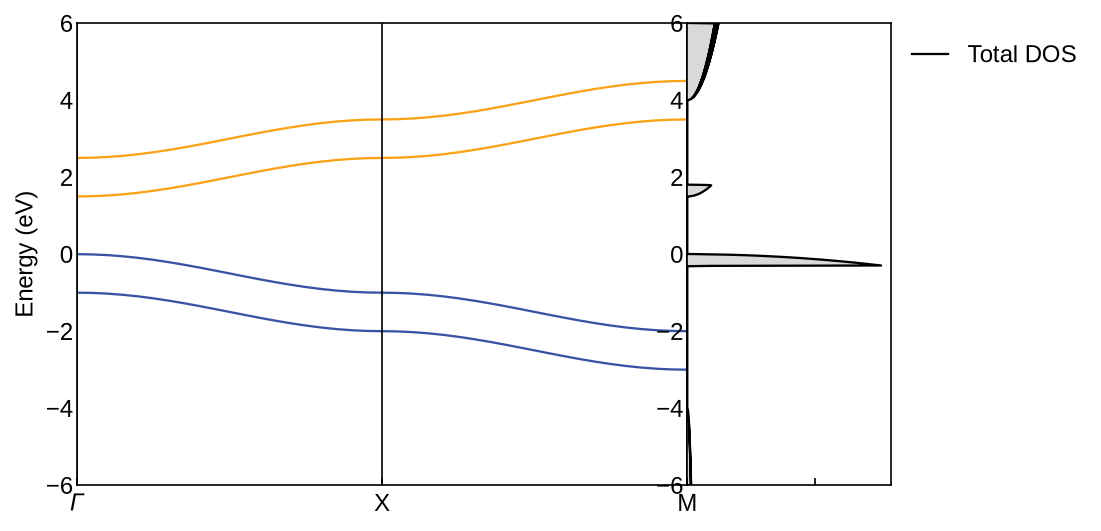

In [13]:
bs = band_structure.get_band_structure(str(castep_data / "BAND"), 1, code="castep")

# sumo's pretty_subplot does not create axes when handed an existing plt, so a
# two-panel figure has to exist before the call for the DOS side panel to land.
plt.subplots(1, 2, figsize=(7, 4), dpi=150, gridspec_kw={"width_ratios": [3, 1], "wspace": 0})

band_structure.plot_band_structure(
    bs,
    plt,
    ymin=-6,
    ymax=6,
    dos_file=str(castep_data / "DOS" / "toy.bands"),
    code="castep",
)

fundamental_gap = bs.get_band_gap()
E_gap_fundamental = fundamental_gap["energy"]
E_gap_direct = bs.get_direct_band_gap()
print(f"Band gap = {E_gap_fundamental:.4f} eV, {fundamental_gap['transition']}")
print(f"Direct band gap = {E_gap_direct:.4f} eV")

The gap comes back as exactly the 1.5 eV the fixture encodes, direct at Γ, and the labels Γ-X-M are the ones in `toy.cell`. The DOS panel's features beyond ±4 eV are the fixture rather than the reader: `DOS/toy.bands` carries far-lying sentinel eigenvalues so that every band sits entirely on one side of the Fermi energy, which is what stops sumo's metal detection from disabling the valence-band-maximum referencing the effective-mass fit depends on.

### Optical absorption and the dielectric constant

`calc_dielectric` reads the OptaDOS `_epsilon.dat` when given `code="castep"`. The static dielectric constant is taken from the lowest-energy row, matching the VASP convention of reading it off the zero-energy limit; a polycrystalline spectrum comes back as an isotropic tensor.

In [14]:
eps_inf, eps_inf_tensor, _, _, _ = optics.calc_dielectric(
    filename=str(castep_data / "OPT" / "toy_epsilon.dat"),
    code="castep",
)

print("E_inf:", eps_inf)
print("")
print("E_inf tensor:")
print(eps_inf_tensor)

E_inf: 6.0

E_inf tensor:
[[6. 0. 0.]
 [0. 6. 0.]
 [0. 0. 6.]]


The directory-based functions — `plot_absorption`, `generate_absorption`, `generate_n_real` — find the epsilon file by globbing for a single `*_epsilon.dat`. If a directory holds more than one calculation, name the seed with `seedname=`.

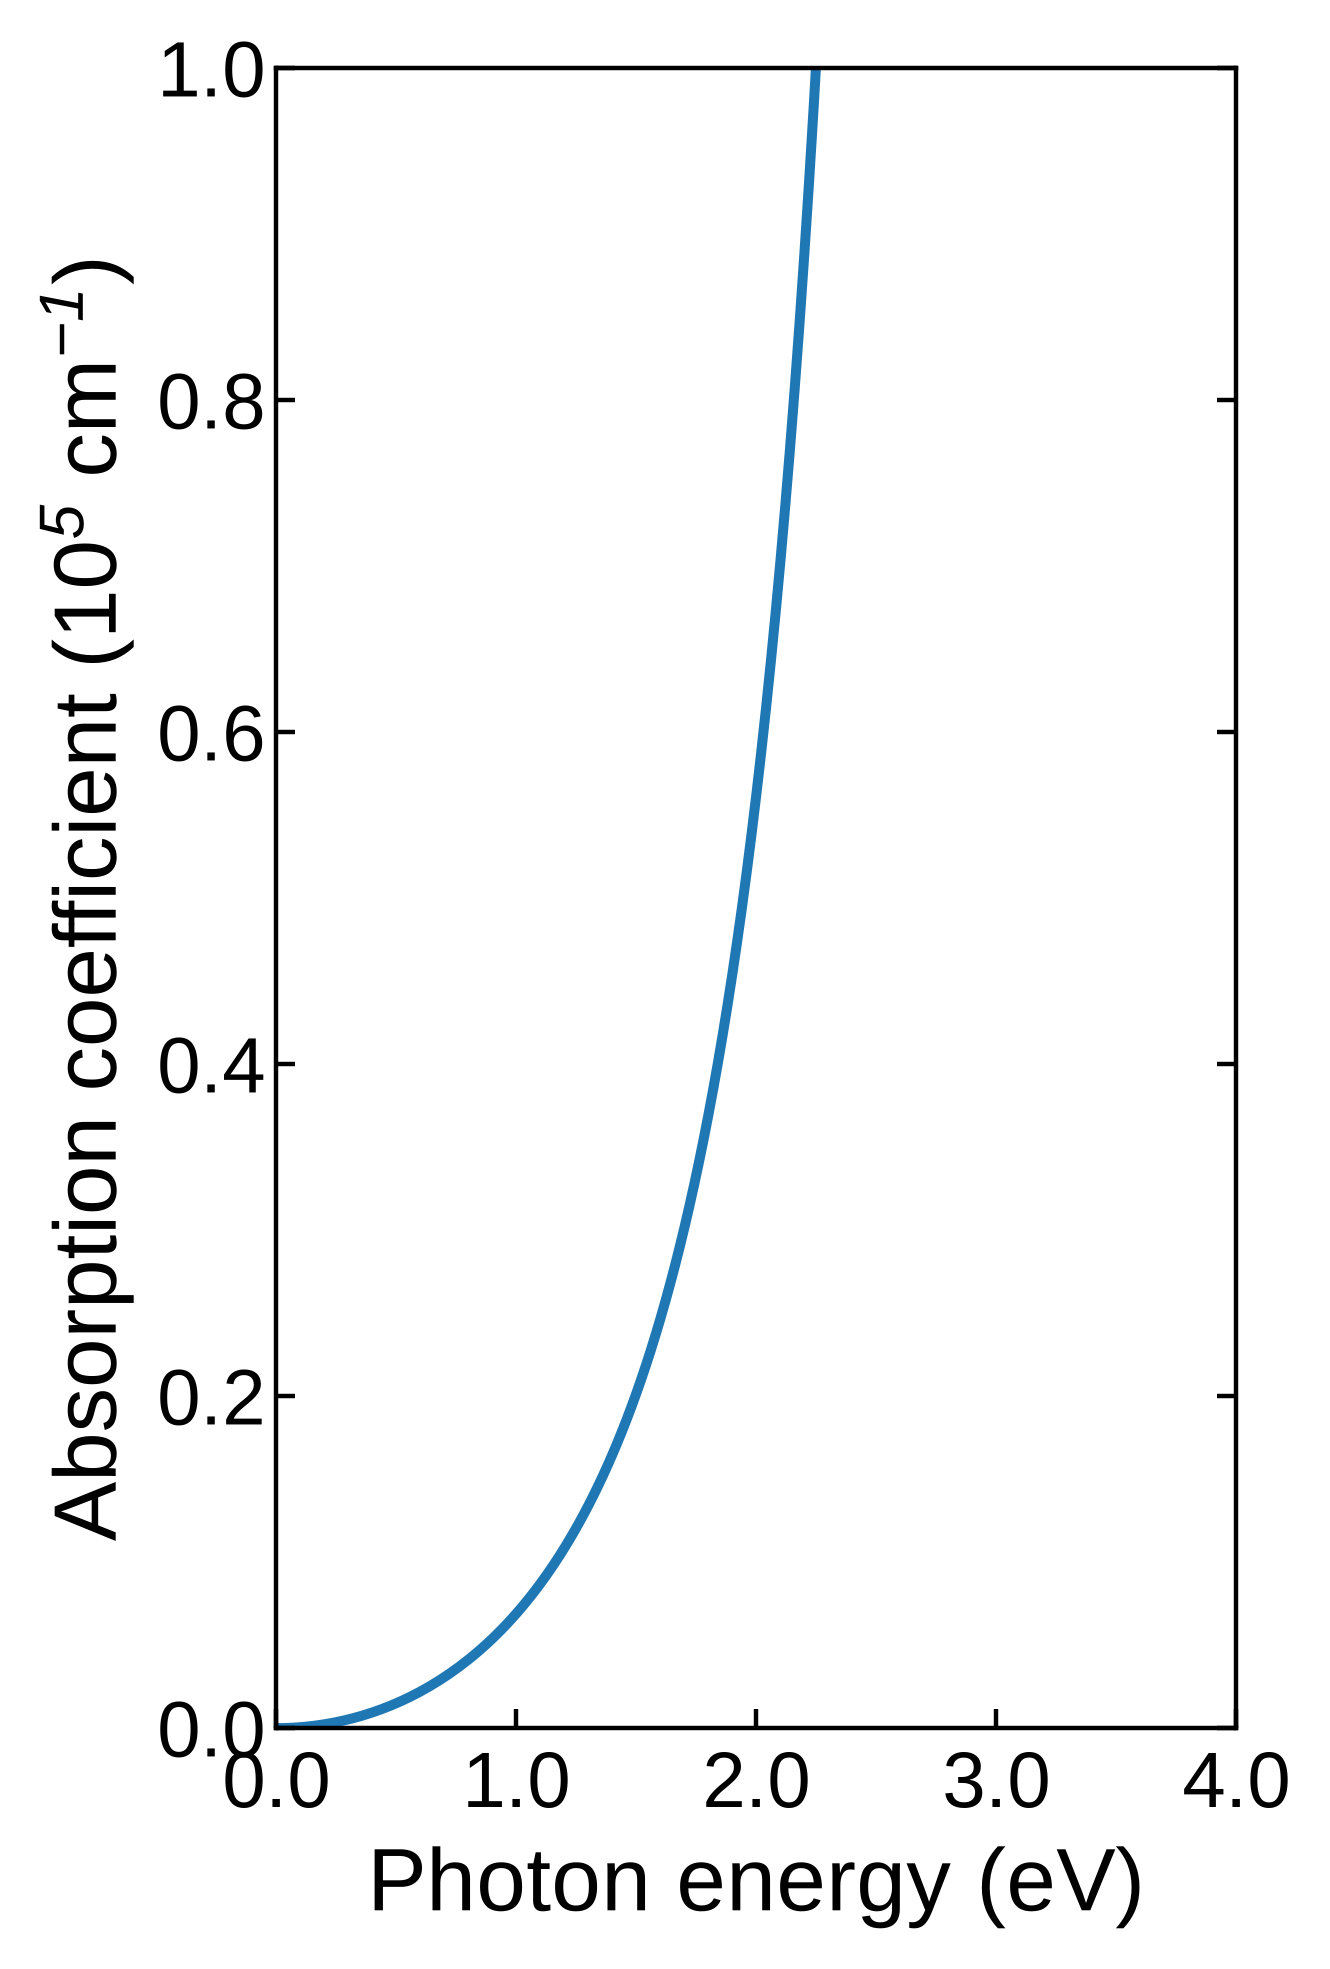

In [15]:
optics.plot_absorption(optics_directory=str(castep_data / "OPT"), code="castep")

There is no absorption onset at the gap in that spectrum, because the fixture is a bare Lorentz oscillator rather than a calculated joint density of states: it absorbs weakly at every energy. A real material's would rise from zero at the absorption edge.

`generate_absorption` and `generate_n_real` write the `absorption.dat` and `n_real.dat` that everything downstream consumes. Once they exist, the CASTEP path is over — no function after this point takes a `code` argument, and the files are in the same format the VASP path produces.

In [16]:
optics_analysis = workdir / "OPT_analysis"
optics_analysis.mkdir(parents=True, exist_ok=True)

optics.generate_absorption(str(castep_data / "OPT"), out_directory=optics_analysis, code="castep")
optics.generate_n_real(str(castep_data / "OPT"), out_directory=optics_analysis, code="castep")

print(sorted(p.name for p in optics_analysis.iterdir()))

['absorption.dat', 'n_real.dat']


### SLME and the Blank et al. metrics

Maximum efficiency against film thickness, from the absorption spectrum and refractive index just written.

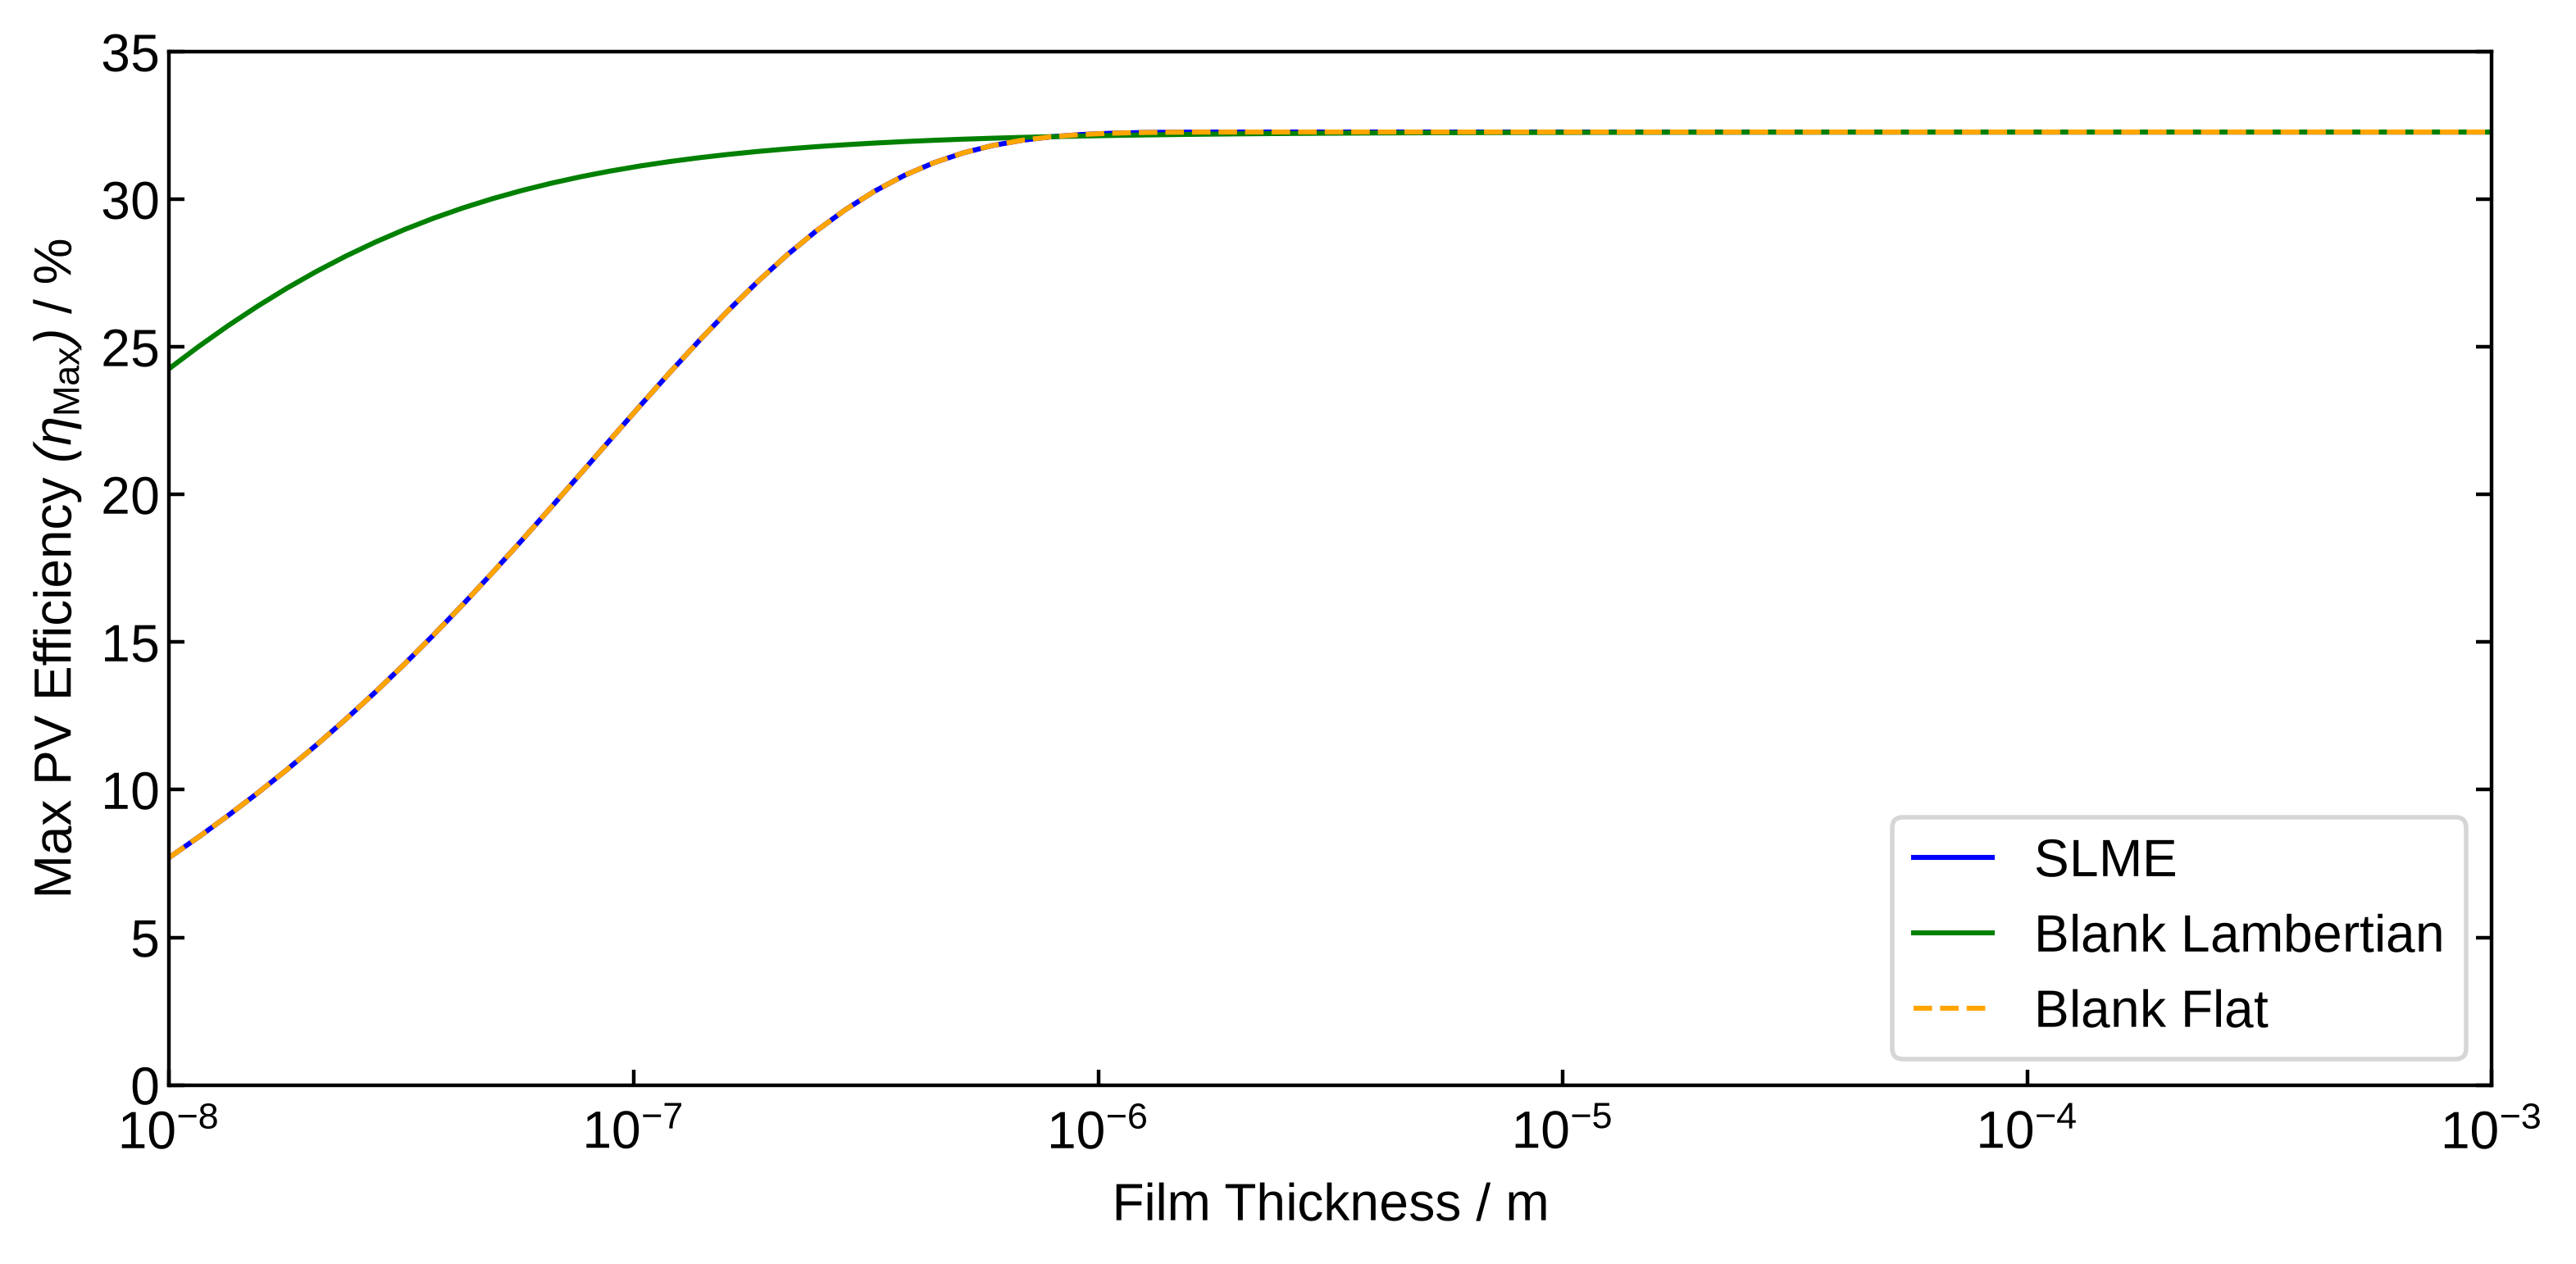

In [17]:
optics.make_blank_plot(
    str(optics_analysis),
    direct_gap=E_gap_direct,
    indirect_gap=E_gap_direct,
    spectrum_type="AM1.5",
    Qi=1.0,
    n=3.5,
    thickness_range=None,
    save=False,
)

### Detailed balance and the Shockley-Queisser limit

Supplying a band gap and an operating temperature is enough for the detailed-balance results. The spectrum can be any of `"AM1.5"`, `"Fluorescent"`, `"Blue LED"`, `"Green LED"`, `"Red LED"`, `"White LED"`, `"IR LED"` or `"Photopic"`.

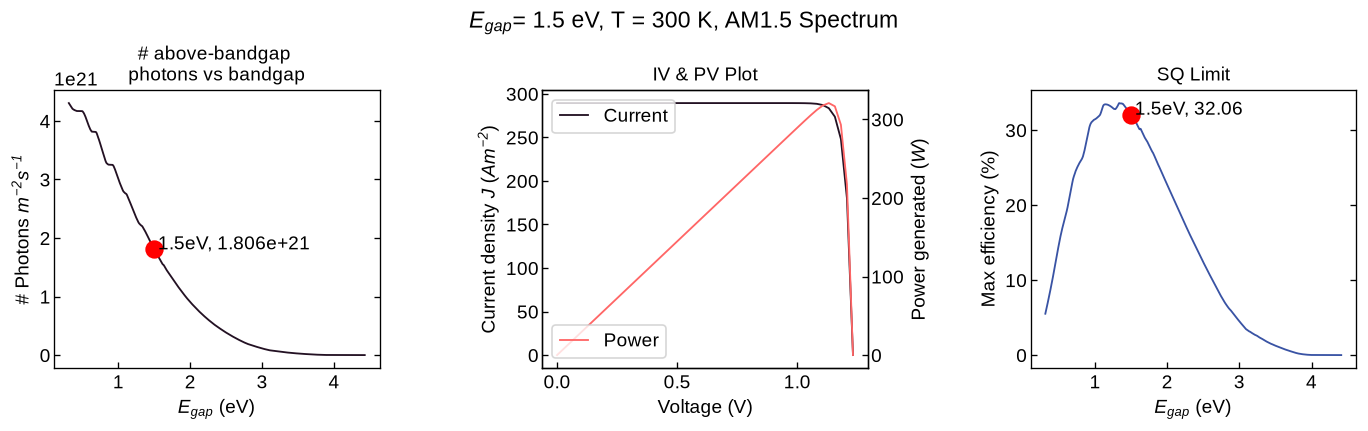

In [18]:
Tcell = 300  # Operating temperature in K
spectrum_type = "AM1.5"

spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)
photon_spectrum = db_fom.convert_spectrum(spectrum)

db_plots.plot_db_combined(
    photon_spectrum,
    Egap=round(E_gap_direct, 3),
    Tcell=Tcell,
    spectrum_type=spectrum_type,
)

`db_plots.plot_db_combined_interactive` and `final_results.plot_final_result_interactive` put sliders on these, for exploring the parameter space rather than reporting a single material. They need the `ipympl` backend (`pip install -e ".[interactive]"`) and `%matplotlib widget`; the [VASP tutorial](https://solphin.readthedocs.io/en/latest/full_workflow_tutorial.html) demonstrates both, and neither cares which code produced the data.

## The photovoltaic figure of merit

The last step gathers the calculated properties together with the transport parameters. The spectral average and dispersion of the absorption coefficient come from the `absorption.dat` written above, weighted by the photon flux of the incident spectrum over the range the gap defines.

In [19]:
spectral_average, spectral_dispersion = spectral.generate_spectral_parameters(
    str(optics_analysis),
    spectrum,
    E_gap=E_gap_direct,
)

print(f"Spectral average (alpha):    {spectral_average:.4e} cm^-1")
print(f"Spectral dispersion (sigma): {spectral_dispersion:.4f}")

Spectral average (alpha):    1.9776e+05 cm^-1
Spectral dispersion (sigma): 0.6445


Carrier lifetime, doping density and mobility are not calculated by this workflow. The values below are the representative ones from Crovetto (2024); replace them with measurements, or with numbers from a defect study, when you have them. Any of the calculated quantities can be overwritten the same way — the figure of merit takes plain floats.

In [20]:
tau = 1e-6  # Carrier lifetime in s
doping_density = 1e10  # Doping density in cm^-3
mu = 1e6  # Carrier mobility in cm^2 V^-1 s^-1

sq, fom_sq, eff = final_results.SQ_relative_FOM_PV_efficiency(
    E_gap_direct,
    photon_spectrum,
    spectral_average,
    tau,
    spectral_dispersion,
    dos_mass,
    doping_density,
    eps_inf,
    mu,
    Tcell,
)

print(f"Photovoltaic Figure of Merit relative to the SQ limit: {fom_sq:.2f} %")
print(f"Photovoltaic Figure of Merit total efficiency: {eff:.2f} %")
print(f"SQ limit: {sq:.2f} %")

Photovoltaic Figure of Merit relative to the SQ limit: 77.17 %
Photovoltaic Figure of Merit total efficiency: 24.74 %
SQ limit: 32.06 %


Those percentages describe a synthetic oscillator, not a candidate absorber. What they demonstrate is that a CASTEP calculation reaches the figure of merit through the same three inputs as a VASP one — a gap from `.bands`, a DOS mass from `.bands`, a dielectric function from OptaDOS — and that the physics between those inputs and this number never learns which code it came from.

## Where to go next

* The ["Using solphin with CASTEP"](https://solphin.readthedocs.io/en/latest/castep.html) page tabulates every reader's CASTEP source file, the full patch mapping, and the recipe caveats (`R2SCAN` maps to CASTEP's `RSCAN`; `elastic_tensor`, `rvv10`, `deformation_potential` and `lobster` are VASP-only and raise `ValueError`).
* The [full workflow tutorial](https://solphin.readthedocs.io/en/latest/full_workflow_tutorial.html) runs the same analysis on real VASP data for Cu₂GeS₃, and covers the interactive explorers.
* `tests/castep_fixtures.py` documents how each file read here was constructed, if you want to know exactly what was fed to the readers.